# Wine Quality Classification
## POSTECH — Data Analytics Tech Challenge — Fase 2

**Objetivo:** Desenvolver um modelo de classificação capaz de prever se um vinho tinto é de **alta qualidade (nota ≥ 7)** ou **baixa/média qualidade (nota < 7)** com base em suas características físico-químicas.

---
### Estrutura do notebook

1. Configuração do ambiente
2. Carga e inspeção inicial dos dados
3. Análise Exploratória de Dados (EDA)
4. Pré-processamento
5. Desenvolvimento dos modelos
6. Avaliação e comparação
7. Interpretação dos resultados


## 1. Configuração do ambiente

In [45]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Configuração visual padrão
sns.set_theme(style='whitegrid', palette='RdPu')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print('Ambiente configurado com sucesso.')


Ambiente configurado com sucesso.


## 2. Carga e inspeção inicial dos dados

O dataset **WineQT** contém 1.143 amostras de vinho tinto com 11 variáveis físico-químicas e uma nota de qualidade atribuída por especialistas (escala de 3 a 8).


In [ ]:
# Carrega o dataset — ajuste o caminho se necessário
df_raw = pd.read_csv('data/WineQT.csv')

print(f'Dimensões: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas')
df_raw.head()


FileNotFoundError: [Errno 2] No such file or directory: '/wine-quality-classification/data/WineQT.csv'

In [ ]:
# Tipos de dados e valores nulos
print('=== Tipos de dados e nulos ===')
info = pd.DataFrame({
    'Tipo'  : df_raw.dtypes,
    'Nulos' : df_raw.isnull().sum(),
    '% Nulo': (df_raw.isnull().mean() * 100).round(2)
})
print(info)


=== Tipos de dados e nulos ===
                         Tipo  Nulos  % Nulo
fixed acidity         float64      0     0.0
volatile acidity      float64      0     0.0
citric acid           float64      0     0.0
residual sugar        float64      0     0.0
chlorides             float64      0     0.0
free sulfur dioxide   float64      0     0.0
total sulfur dioxide  float64      0     0.0
density               float64      0     0.0
pH                    float64      0     0.0
sulphates             float64      0     0.0
alcohol               float64      0     0.0
quality                 int64      0     0.0
Id                      int64      0     0.0


In [ ]:
# Estatísticas descritivas
df_raw.describe().round(3)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000
mean,8.311,0.531,0.268,2.532,0.087,15.615,45.915,0.997,3.311,0.658,10.442,5.657,804.969
std,1.748,0.180,0.197,1.356,0.047,10.250,32.782,0.002,0.157,0.170,1.082,0.806,463.997
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000,0.000
25%,7.100,0.392,0.090,1.900,0.070,7.000,21.000,0.996,3.205,0.550,9.500,5.000,411.000
50%,7.900,0.520,0.250,2.200,0.079,13.000,37.000,0.997,3.310,0.620,10.200,6.000,794.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,61.000,0.998,3.400,0.730,11.100,6.000,1209.500
max,15.900,1.580,1.000,15.500,0.611,68.000,289.000,1.004,4.010,2.000,14.900,8.000,1597.000


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Criação da variável alvo binária

Transformamos a nota de qualidade em uma classificação binária:
- **1 → Alta qualidade** (nota ≥ 7)
- **0 → Baixa/Média qualidade** (nota < 7)


In [ ]:
# Cria cópia de trabalho e remove coluna Id (sem valor preditivo)
df = df_raw.drop(columns=['Id']).copy()

# Variável alvo binária como inteiro (0/1) — formato esperado pelo scikit-learn
df['binary_quality'] = (df['quality'] >= 7).astype(int)

# Versão textual apenas para visualizações
df['quality_category'] = df['binary_quality'].map({1: 'Alta qualidade', 0: 'Baixa/Média qualidade'})

print('Distribuição da variável alvo:')
print(df['binary_quality'].value_counts())
print()
print(f"Alta qualidade  : {(df['binary_quality']==1).sum()} ({(df['binary_quality']==1).mean()*100:.1f}%)")
print(f"Baixa/Média     : {(df['binary_quality']==0).sum()} ({(df['binary_quality']==0).mean()*100:.1f}%)")


Distribuição da variável alvo:
binary_quality
0    984
1    159
Name: count, dtype: int64

Alta qualidade  : 159 (13.9%)
Baixa/Média     : 984 (86.1%)


### 💡 Por que transformar a qualidade em variável binária?

A nota original de qualidade varia de **3 a 8**, mas a distribuição é concentrada entre 5 e 6 (mais de 81% das amostras). Treinar um modelo com 6 classes distintas seria problemático por dois motivos:

1. **Classes com poucas amostras**: notas 3 (6 amostras) e 8 (16 amostras) teriam exemplos insuficientes para o modelo aprender.
2. **Subjetividade dos limites**: a diferença entre nota 5 e 6 é mais subjetiva do que a diferença entre "bom" e "não bom".

O corte em **nota ≥ 7** segue a definição do Tech Challenge e representa um ponto natural de separação: vinhos que superaram as expectativas dos especialistas avaliadores. O valor é armazenado como **inteiro (0/1)** — formato exigido pelo scikit-learn para classificação binária.


### 3.2 Balanceamento das classes

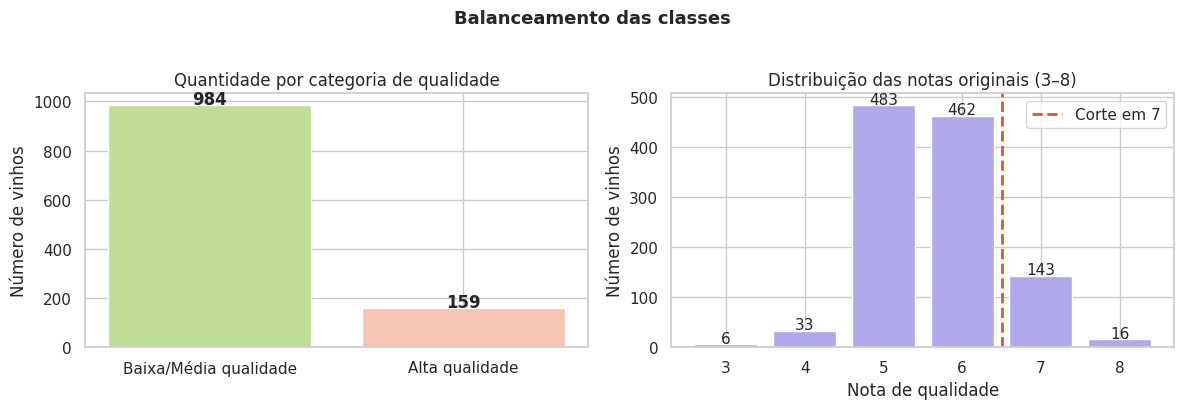

⚠ Dataset desbalanceado: apenas 13,9% são de alta qualidade.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
counts = df['quality_category'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#C0DD97', '#F5C4B3'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Quantidade por categoria de qualidade')
axes[0].set_ylabel('Número de vinhos')
axes[0].set_xlabel('')

# Distribuição das notas originais
note_counts = df['quality'].value_counts().sort_index()
axes[1].bar(note_counts.index, note_counts.values, color='#AFA9EC', edgecolor='white')
axes[1].axvline(x=6.5, color='#D85A30', linestyle='--', linewidth=2, label='Corte em 7')
for i, (nota, v) in enumerate(note_counts.items()):
    axes[1].text(nota, v + 3, str(v), ha='center', fontsize=11)
axes[1].set_title('Distribuição das notas originais (3–8)')
axes[1].set_ylabel('Número de vinhos')
axes[1].set_xlabel('Nota de qualidade')
axes[1].legend()

plt.suptitle('Balanceamento das classes', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/01_balanceamento_classes.png', bbox_inches='tight')
plt.show()
print('⚠ Dataset desbalanceado: apenas 13,9% são de alta qualidade.')


### 💡 O que o desbalanceamento implica para a modelagem?

Com apenas **13,9% de vinhos de alta qualidade**, o dataset é severamente desbalanceado. Isso cria um risco crítico: um modelo ingênuo que sempre responde "baixa/média qualidade" alcançaria **86,1% de acurácia** sem aprender nada.

Por isso, **acurácia não será usada como métrica principal**. Usaremos:
- **F1-Score**: equilíbrio entre encontrar vinhos bons e não alarmar falsos positivos
- **Recall**: garantir que o modelo encontre a maior parte dos vinhos bons
- **AUC-ROC**: capacidade geral de separação entre classes

O desbalanceamento será corrigido na etapa de pré-processamento com **SMOTE**.


### 3.3 Distribuição das variáveis por classe

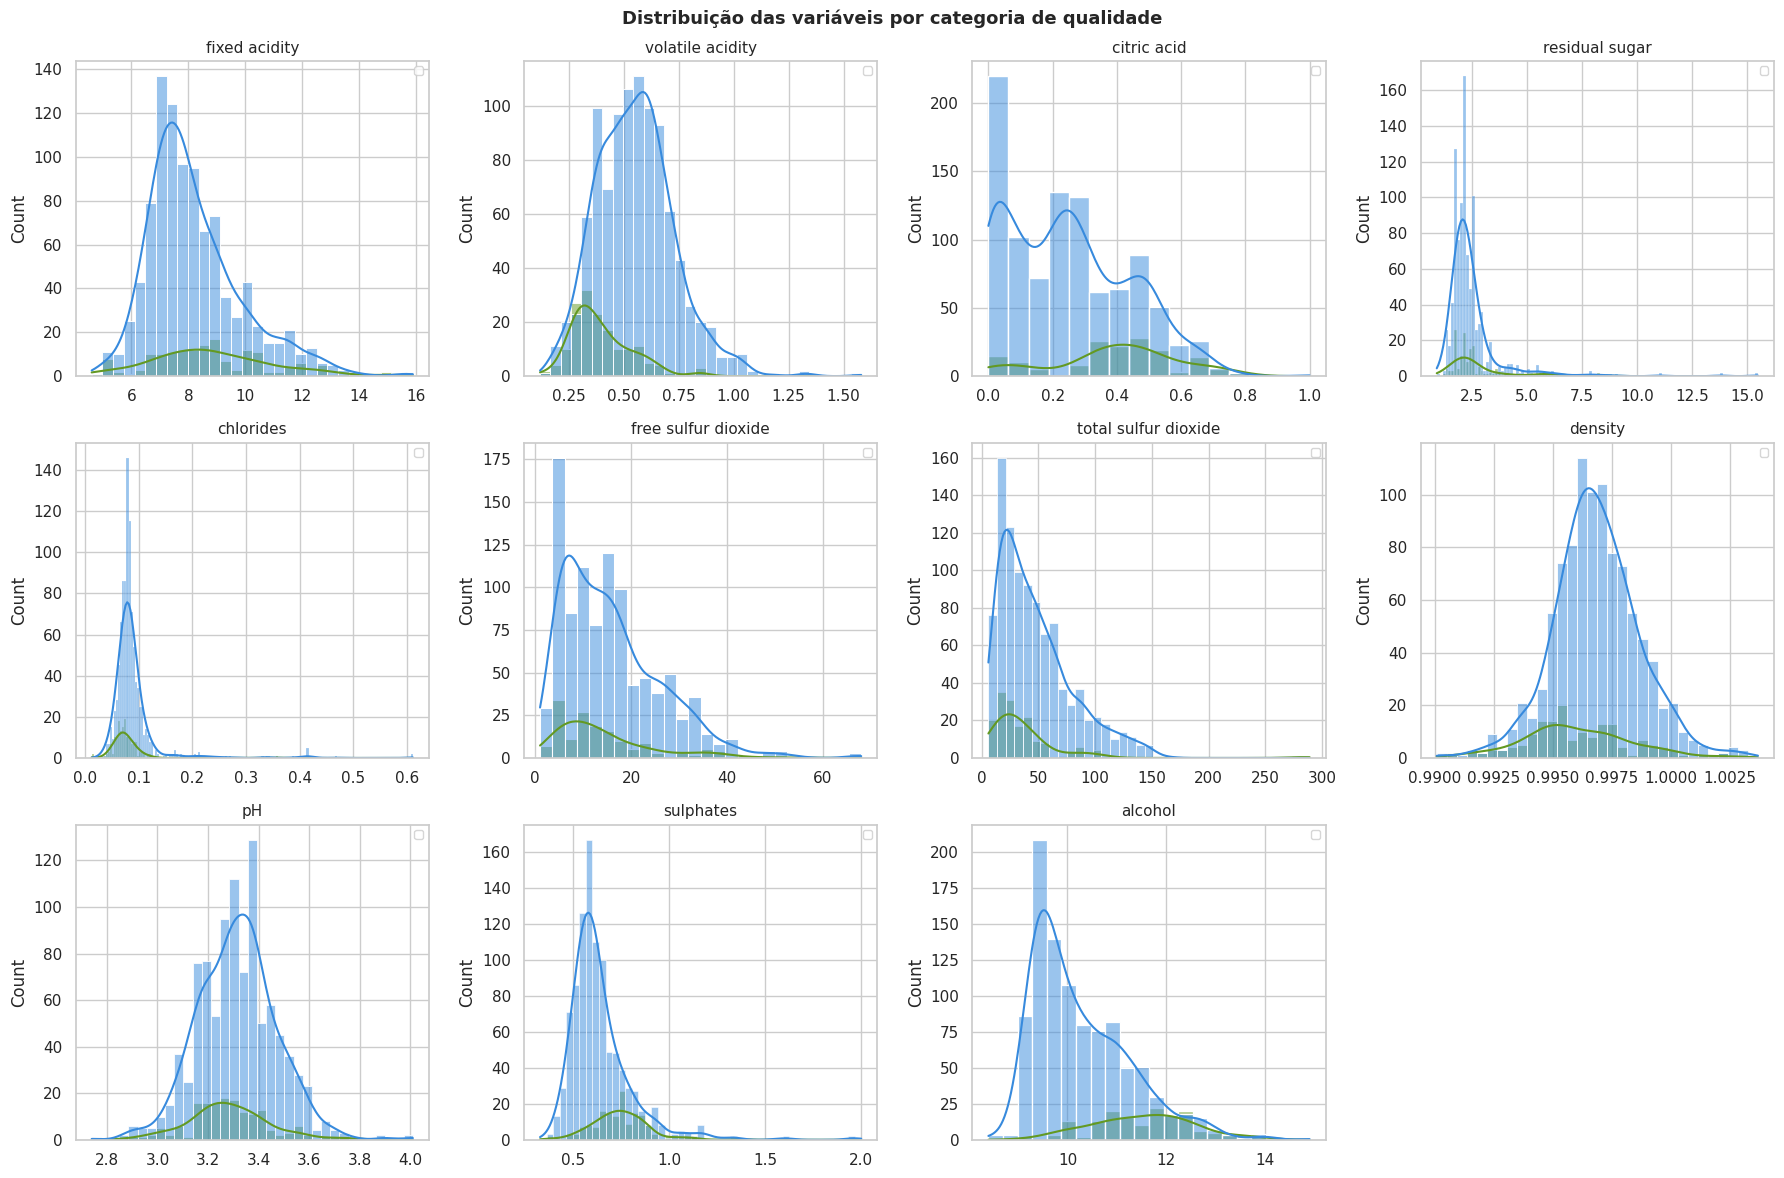

In [ ]:
features = [c for c in df.columns if c not in ['quality', 'binary_quality', 'quality_category']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(
        data=df, x=feat, hue='quality_category', kde=True, ax=axes[i],
        palette={'Alta qualidade': '#639922', 'Baixa/Média qualidade': '#378ADD'},
        alpha=0.5
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Remove subplot extra
axes[-1].set_visible(False)

plt.suptitle('Distribuição das variáveis por categoria de qualidade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/02_distribuicao_variaveis.png', bbox_inches='tight')
plt.show()


### 💡 O que os histogramas revelam?

Comparando as curvas de densidade entre as duas classes, três variáveis mostram **separação visual clara** — indicando alto poder discriminativo para o modelo:

| Variável | Padrão observado |
|---|---|
| `alcohol` | Vinhos bons concentrados em teores mais altos — curvas bem separadas |
| `volatile acidity` | Vinhos bons concentrados em valores menores — separação evidente |
| `sulphates` | Vinhos bons com distribuição deslocada para valores maiores |

Variáveis como `residual sugar` e `pH` mostram curvas praticamente sobrepostas entre as classes — sugerindo **baixo poder preditivo isolado**. Isso será confirmado pela análise de correlações na próxima seção.


### 3.4 Faixas categóricas das variáveis mais relevantes

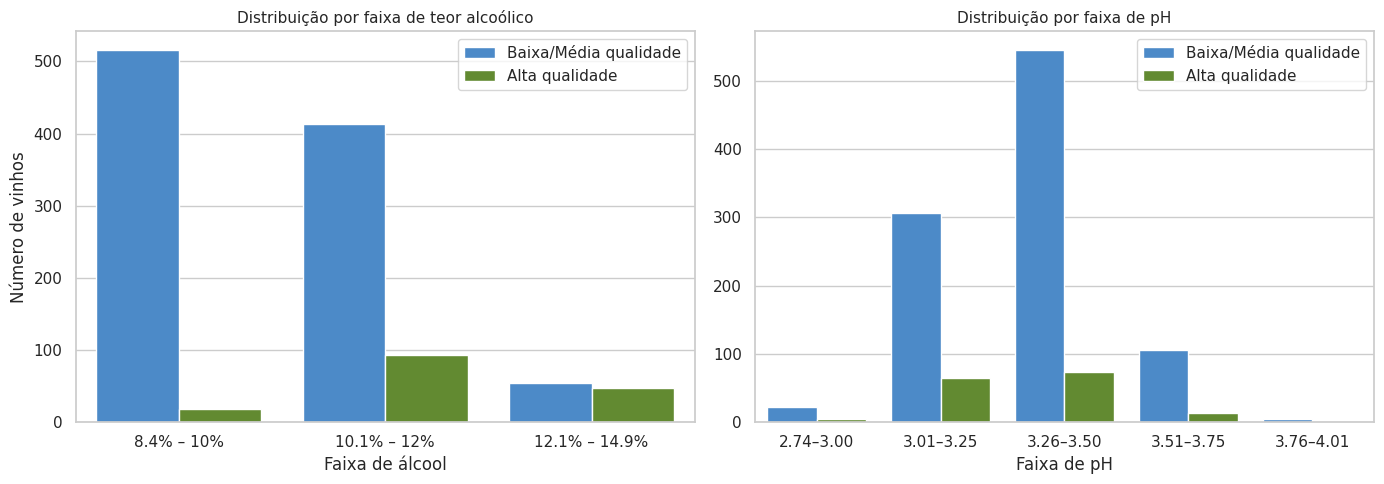

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Faixas de teor alcoólico
alcohol_bins   = [8.3, 10.0, 12.0, 14.9]
alcohol_labels = ['8.4% – 10%', '10.1% – 12%', '12.1% – 14.9%']
df['faixa_alcool'] = pd.cut(df['alcohol'], bins=alcohol_bins, labels=alcohol_labels)

order_alc = alcohol_labels
sns.countplot(x='faixa_alcool', hue='quality_category', data=df, order=order_alc,
              palette={'Alta qualidade': '#639922', 'Baixa/Média qualidade': '#378ADD'},
              ax=axes[0])
axes[0].set_title('Distribuição por faixa de teor alcoólico', fontsize=11)
axes[0].set_xlabel('Faixa de álcool')
axes[0].set_ylabel('Número de vinhos')
axes[0].legend(title='')

# Faixas de pH
pH_bins   = [2.73, 3.00, 3.25, 3.50, 3.75, 4.01]
pH_labels = ['2.74–3.00', '3.01–3.25', '3.26–3.50', '3.51–3.75', '3.76–4.01']
df['faixa_ph'] = pd.cut(df['pH'], bins=pH_bins, labels=pH_labels)

sns.countplot(x='faixa_ph', hue='quality_category', data=df, order=pH_labels,
              palette={'Alta qualidade': '#639922', 'Baixa/Média qualidade': '#378ADD'},
              ax=axes[1])
axes[1].set_title('Distribuição por faixa de pH', fontsize=11)
axes[1].set_xlabel('Faixa de pH')
axes[1].set_ylabel('')
axes[1].legend(title='')

plt.tight_layout()
plt.savefig('results/03_faixas_categoricas.png', bbox_inches='tight')
plt.show()


### 💡 O que as faixas revelam em linguagem de negócio?

**Teor alcoólico**: na faixa de 12,1% a 14,9%, a proporção de vinhos de alta qualidade é significativamente maior. Já na faixa abaixo de 10%, vinhos bons são raros. Isso sugere que o **processo de fermentação** — que define o teor alcoólico — é um indicador precoce da qualidade final.

**pH**: a distribuição por faixa de pH é mais uniforme entre as classes, confirmando que o pH isolado tem **baixo poder discriminativo** (correlação de -0,05 com a qualidade). O pH influencia a qualidade em conjunto com outras variáveis ácidas, não de forma isolada.


### 3.5 Correlações entre variáveis

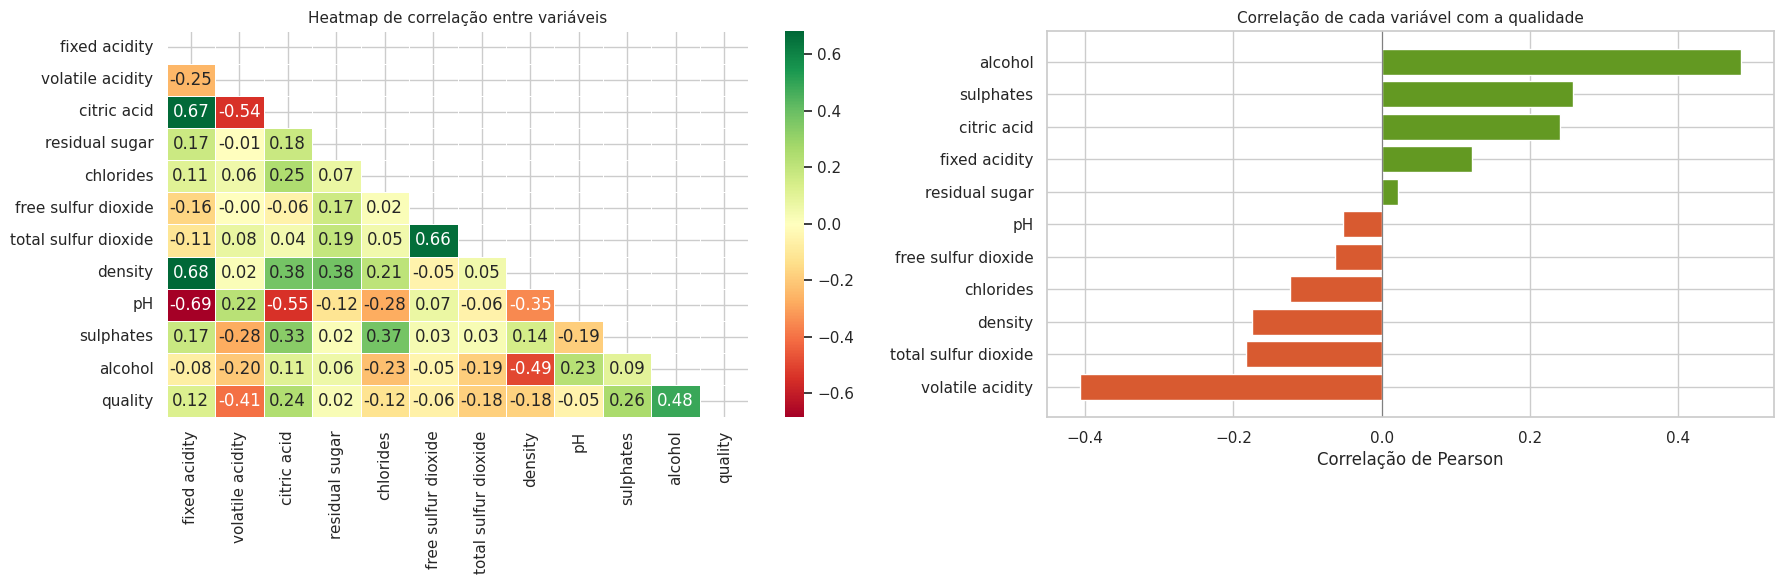


Correlações com a qualidade (ordenadas):
volatile acidity       -0.407
total sulfur dioxide   -0.183
density                -0.175
chlorides              -0.124
free sulfur dioxide    -0.063
pH                     -0.052
residual sugar          0.022
fixed acidity           0.122
citric acid             0.241
sulphates               0.258
alcohol                 0.485


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap de correlação geral
numeric_cols = features + ['quality']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Heatmap de correlação entre variáveis', fontsize=11)

# Correlação de cada variável com a qualidade
corr_quality = df[features].corrwith(df['quality']).sort_values()
colors = ['#D85A30' if v < 0 else '#639922' for v in corr_quality.values]
axes[1].barh(corr_quality.index, corr_quality.values, color=colors)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Correlação de cada variável com a qualidade', fontsize=11)
axes[1].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.savefig('results/04_correlacoes.png', bbox_inches='tight')
plt.show()

print('\nCorrelações com a qualidade (ordenadas):')
print(corr_quality.round(3).to_string())


### 💡 Justificativa das correlações com a qualidade

#### Correlações positivas (mais valor → melhor qualidade)

**`alcohol` (+0,484) — correlação mais forte**
O teor alcoólico é o maior indicador individual de qualidade. Vinhos de alta qualidade têm em média **11,5% de álcool** contra **10,3% dos comuns** (+12,3%). O álcool resulta da fermentação dos açúcares da uva: uma fermentação mais completa indica uvas mais maduras, processo mais bem conduzido e, consequentemente, vinho de melhor qualidade.

**`sulphates` (+0,257)**
Sulfatos atuam como conservante e antioxidante natural. Vinhos bons têm média de **0,75 g/L** contra **0,64 g/L dos comuns** (+15,9%). Níveis adequados de sulfato protegem o vinho contra oxidação e crescimento bacteriano durante o envelhecimento, preservando aroma e sabor. É um indicador de **qualidade do processo de conservação**.

**`citric acid` (+0,241)**
O ácido cítrico contribui para o frescor e equilíbrio do sabor. A diferença é expressiva: vinhos bons têm **57,4% mais** ácido cítrico em média (0,39 vs 0,25 g/L). Ele neutraliza parcialmente a acidez volátil, melhora o equilíbrio sensorial e é um marcador de vinhos mais cuidadosamente elaborados.

**`fixed acidity` (+0,122) — correlação fraca**
A acidez fixa (predominantemente ácido tartárico) contribui levemente para a qualidade. A diferença entre classes é pequena (+7,6%), sugerindo que a acidez fixa é necessária mas não suficiente — seu efeito depende do equilíbrio com outras variáveis.

#### Correlações negativas (mais valor → pior qualidade)

**`volatile acidity` (-0,407) — segundo fator mais importante**
A acidez volátil mede principalmente ácido acético — o mesmo componente do vinagre. Vinhos de alta qualidade têm **28,6% menos** acidez volátil (0,40 vs 0,55 g/L). Valores elevados indicam **contaminação bacteriana ou oxidação** durante o processo produtivo, gerando sabor e aroma de vinagre. É o principal sinal de defeito de produção neste dataset.

**`total sulfur dioxide` (-0,183)**
O dióxido de enxofre total em excesso altera negativamente o aroma e pode deixar sabor residual amargo. Vinhos de alta qualidade têm **22,6% menos** SO₂ total (36,7 vs 47,4 mg/L), indicando menor necessidade de intervenção química — o que reflete um processo produtivo mais controlado e uvas de melhor procedência.

**`density` (-0,175)**
A densidade está inversamente correlacionada com o álcool (r = -0,49 entre as duas variáveis). Vinhos com mais álcool são menos densos, pois o álcool é menos denso que a água. A correlação negativa da densidade com a qualidade é, portanto, **um reflexo indireto** da correlação positiva do álcool.

**`chlorides` (-0,124)**
Excesso de cloretos (sais) prejudica o sabor do vinho, conferindo gosto salgado. Vinhos bons têm **16,0% menos** cloretos em média. Esta variável tem correlação moderada com a qualidade e é sensível à procedência das uvas e ao processo de irrigação.

#### Correlações próximas de zero (pouco discriminativas isoladamente)

**`free sulfur dioxide` (-0,063)**
O SO₂ livre atua como conservante, mas sua correlação com a qualidade é muito fraca. Isso ocorre porque o efeito real depende do pH e da relação com o SO₂ total — isoladamente, o SO₂ livre tem pouco poder preditivo. Note também a forte correlação entre `free sulfur dioxide` e `total sulfur dioxide` (r = 0,66), indicando **redundância parcial** entre essas variáveis.

**`pH` (-0,052)**
O pH mede a acidez global, mas sua correlação isolada com a qualidade é negligenciável. O pH influencia a qualidade indiretamente — ao modular o efeito de outros ácidos — mas não é um preditor direto. A diferença média entre classes é de apenas 1% (3,28 vs 3,32).

**`residual sugar` (+0,022) — sem correlação linear**
O açúcar residual apresenta a menor correlação com a qualidade de todo o dataset. Isso ocorre porque este dataset contém apenas vinhos tintos secos, onde o açúcar residual é naturalmente baixo e varia pouco entre amostras. Em vinhos doces ou semi-secos, essa variável teria muito maior relevância.

---
> **Atenção metodológica**: as correlações de Pearson capturam apenas relações **lineares**. O modelo Random Forest capturará relações não-lineares e interações entre variáveis que este coeficiente não detecta — por isso variáveis com baixa correlação linear ainda podem ter importância no modelo final.


### 3.6 Boxplots por classe — comparação direta

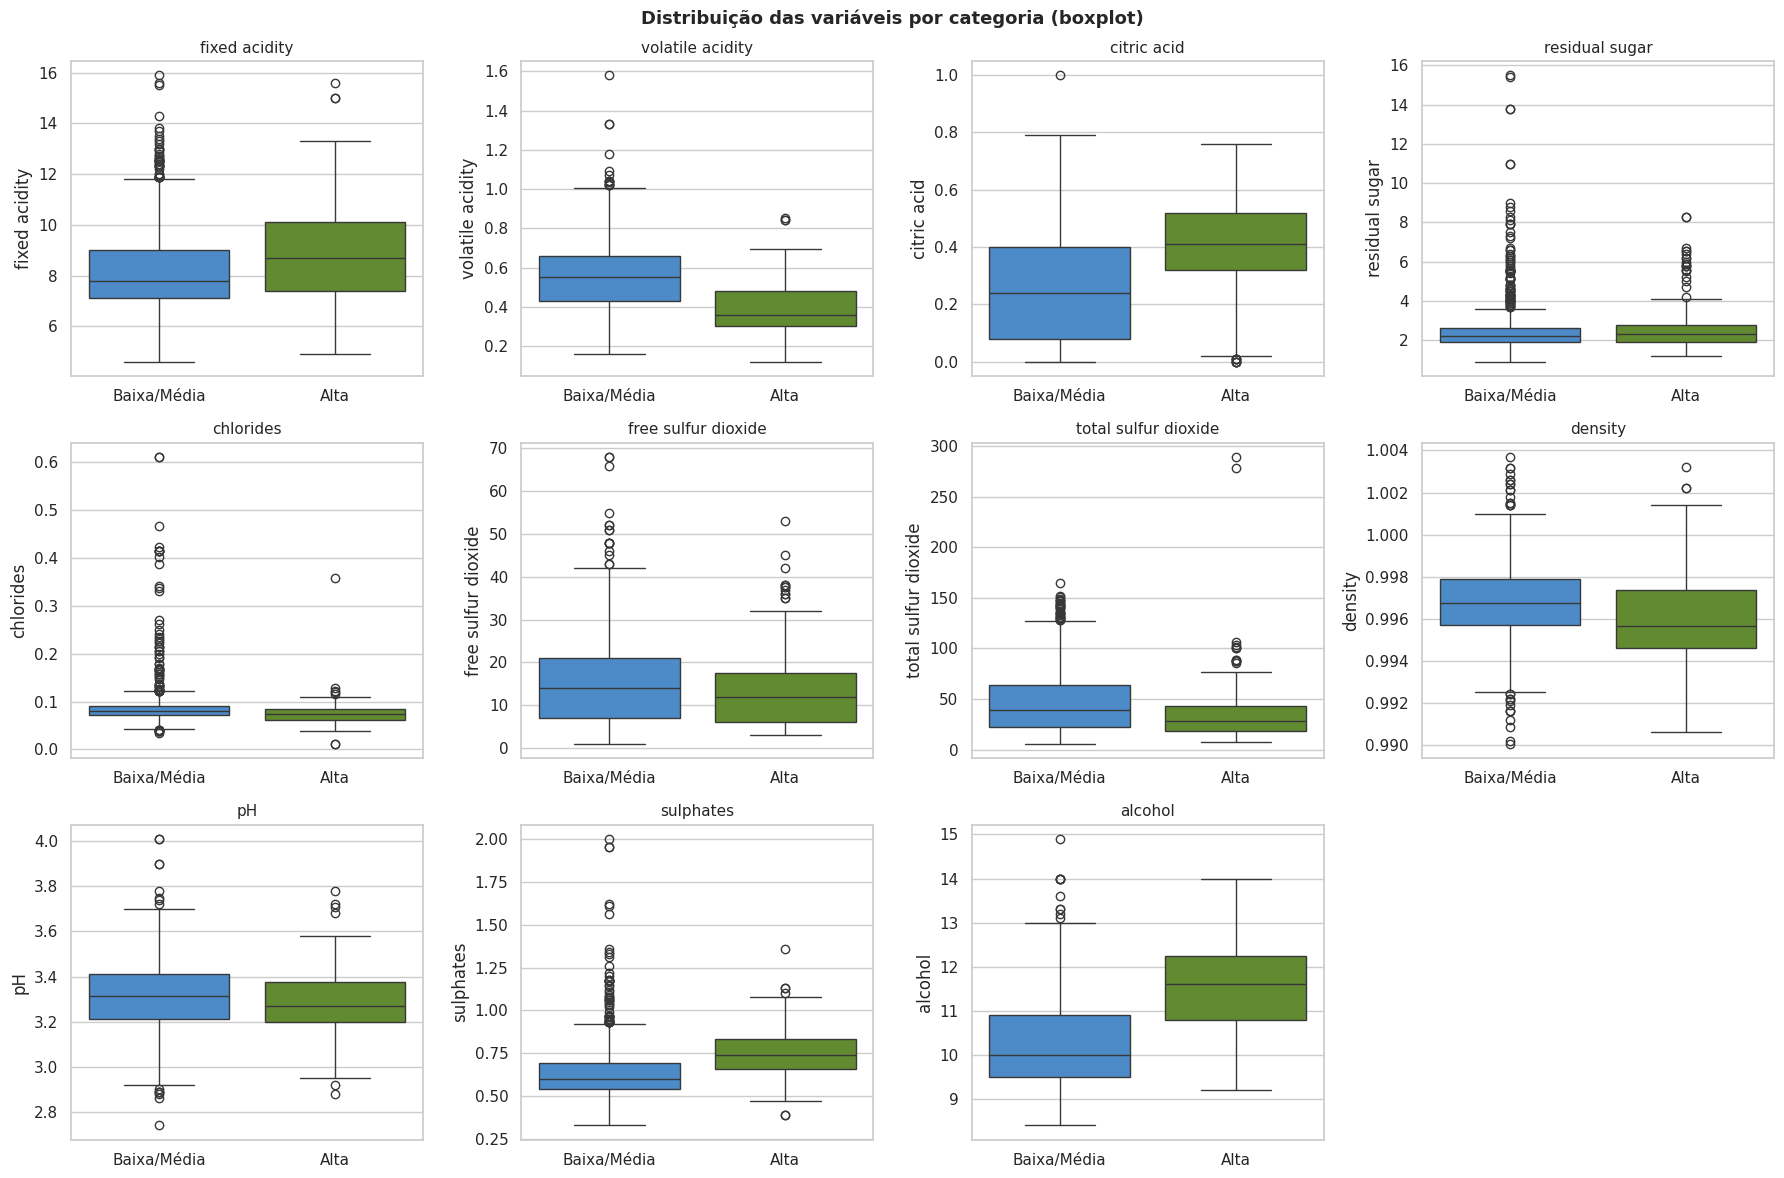

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(
        data=df, x='binary_quality', y=feat, ax=axes[i],
        hue='binary_quality',
        palette={0: '#378ADD', 1: '#639922'},
        legend=False
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Baixa/Média', 'Alta'])
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)

plt.suptitle('Distribuição das variáveis por categoria (boxplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/05_boxplots_por_classe.png', bbox_inches='tight')
plt.show()


### 💡 O que os boxplots acrescentam aos histogramas?

Os boxplots revelam **mediana, dispersão e outliers** de cada variável separados por classe. As diferenças mais evidentes visualmente são:

- **`alcohol`**: a mediana dos vinhos bons está **claramente acima** da dos comuns — a caixa inteira está deslocada para cima
- **`volatile acidity`**: situação inversa — mediana dos vinhos bons está **abaixo** da dos comuns, confirmando ser um indicador de defeito
- **`sulphates`** e **`citric acid`**: medianas diferentes, mas com sobreposição — contribuem para o modelo mas sozinhos não separam perfeitamente as classes

Variáveis como `residual sugar` e `pH` mostram medianas praticamente idênticas entre as classes, reforçando seu baixo poder discriminativo individual.


### 3.7 Detecção de outliers (método IQR)

Outliers detectados por variável:
residual sugar          110
chlorides                77
fixed acidity            44
sulphates                43
total sulfur dioxide     40
density                  36
pH                       20
free sulfur dioxide      18
volatile acidity         14
alcohol                  12
citric acid               1


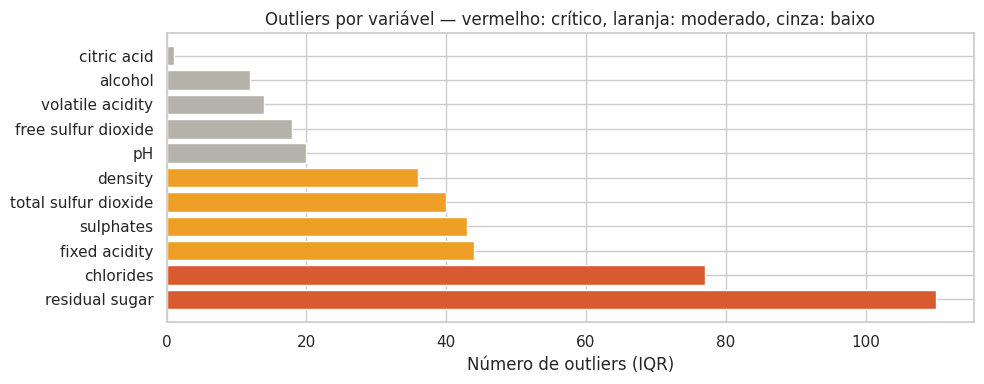

In [ ]:
outlier_counts = {}
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    outlier_counts[feat] = n_out

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)
print('Outliers detectados por variável:')
print(outlier_series.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
cores = ['#D85A30' if v > 60 else '#EF9F27' if v > 30 else '#B4B2A9'
         for v in outlier_series.values]
ax.barh(outlier_series.index, outlier_series.values, color=cores)
ax.set_xlabel('Número de outliers (IQR)')
ax.set_title('Outliers por variável — vermelho: crítico, laranja: moderado, cinza: baixo')
plt.tight_layout()
plt.savefig('results/06_outliers.png', bbox_inches='tight')
plt.show()


### 💡 Como os outliers serão tratados — e por quê?

Foram identificados outliers em todas as 11 variáveis, com graus variados de severidade. A estratégia adotada foi **Winsorização** (não remoção), pelos seguintes motivos:

**Por que não remover linhas:**
Com apenas 1.143 amostras e classes muito desbalanceadas (apenas 159 de alta qualidade), remover linhas com outliers reduziria ainda mais a já escassa classe minoritária, prejudicando o aprendizado.

**Por que Winsorizar:**
A Winsorização substitui valores extremos pelos limites do percentil 1 e 99, **calculados exclusivamente no conjunto de treino**. Isso preserva todas as amostras e elimina o impacto distorcivo dos extremos sem inventar dados novos.

**Variáveis priorizadas para Winsorização:**
- `residual sugar` (110 outliers, skewness 4,35) — distribuição fortemente assimétrica
- `chlorides` (77 outliers, skewness 6,01) — a mais assimétrica do dataset
- `sulphates`, `total sulfur dioxide`, `free sulfur dioxide` — assimetria moderada com quantidade relevante de outliers

**Variáveis não Winsurizadas:**
- `density`, `pH`, `citric acid` — outliers poucos e impacto limitado; o RobustScaler absorve o efeito residual


## 4. Pré-processamento

Etapas aplicadas em sequência, garantindo que nenhuma informação do conjunto de teste vaze para o treino:

1. Separação treino/teste estratificada
2. Winsorização dos outliers críticos (percentis 1–99 calculados no treino)
3. Normalização com RobustScaler (fit apenas no treino)
4. Balanceamento com SMOTE (apenas no treino)


In [ ]:
# Features e target
X = df[features].copy()
y = df['binary_quality'].copy()

# 1. Train/test split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Proporção alta qualidade — treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}')


Treino: 914 amostras | Teste: 229 amostras
Proporção alta qualidade — treino: 13.9% | teste: 14.0%


In [ ]:
# 2. Winsorização — corrige outliers com base nos percentis do treino
cols_win = ['residual sugar', 'chlorides', 'sulphates',
            'total sulfur dioxide', 'free sulfur dioxide']

X_train = X_train.copy()
X_test  = X_test.copy()

for col in cols_win:
    p1  = np.percentile(X_train[col], 1)
    p99 = np.percentile(X_train[col], 99)
    X_train[col] = X_train[col].clip(p1, p99)
    X_test[col]  = X_test[col].clip(p1, p99)

print('Winsorização aplicada nas colunas:', cols_win)


Winsorização aplicada nas colunas: ['residual sugar', 'chlorides', 'sulphates', 'total sulfur dioxide', 'free sulfur dioxide']


In [ ]:
# 3. Normalização — RobustScaler é resistente a outliers residuais
#    fit_transform no treino, apenas transform no teste
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Normalização aplicada. Média pós-escala (treino):', X_train_sc.mean().round(4))


Normalização aplicada. Média pós-escala (treino): 0.1756


In [ ]:
# 4. SMOTE — gera amostras sintéticas da classe minoritária APENAS no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print('Antes do SMOTE :', dict(pd.Series(y_train).value_counts()))
print('Após  o SMOTE  :', dict(pd.Series(y_train_res).value_counts()))


Antes do SMOTE : {0: np.int64(787), 1: np.int64(127)}
Após  o SMOTE  : {0: np.int64(787), 1: np.int64(787)}


### 3.8 Feature Engineering — Avaliação empírica

O Tech Challenge menciona a "criação de novas features se considerado relevante". Em vez de decidir apenas com argumentos teóricos, avaliamos **5 features candidatas empiricamente** usando validação cruzada estratificada (5-fold, métrica F1-Score), comparando cada uma ao baseline com as 11 features originais.

#### Features candidatas avaliadas

| Feature | Fórmula | Hipótese |
|---|---|---|
| `acid_ratio` | `volatile_acidity / (citric_acid + ε)` | Captura o desequilíbrio entre defeito e frescor ácido |
| `so2_ratio` | `free_SO2 / (total_SO2 + ε)` | Proporção de SO₂ ativo vs total — eficiência de conservação |
| `alcohol_density` | `alcohol / density` | Reforça a relação inversa conhecida entre as duas variáveis |
| `sulphate_alcohol` | `sulphates × alcohol` | Interação entre os dois principais fatores positivos |
| `acid_sulfate` | `volatile_acidity × sulphates` | Interação entre defeito e conservante |

> **Metodologia**: cada feature foi testada individualmente adicionada ao conjunto original. O pipeline completo (RobustScaler → SMOTE → Random Forest) foi avaliado com `cross_val_score` em 5 folds estratificados para garantir a proporção de classes em cada fold.


In [ ]:
# ── Feature Engineering: avaliação empírica com validação cruzada ──────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuração da validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 1. Criar features candidatas ─────────────────────────────────────────────
X_fe = X.copy()  # X já sem coluna Id e quality

X_fe['acid_ratio']       = X_fe['volatile acidity'] / (X_fe['citric acid'] + 0.001)
X_fe['so2_ratio']        = X_fe['free sulfur dioxide'] / (X_fe['total sulfur dioxide'] + 0.001)
X_fe['alcohol_density']  = X_fe['alcohol'] / X_fe['density']
X_fe['sulphate_alcohol'] = X_fe['sulphates'] * X_fe['alcohol']
X_fe['acid_sulfate']     = X_fe['volatile acidity'] * X_fe['sulphates']

new_features_fe = ['acid_ratio', 'so2_ratio', 'alcohol_density',
                   'sulphate_alcohol', 'acid_sulfate']

# ── 2. Pipeline de avaliação ─────────────────────────────────────────────────
def avaliar_features(X_df, label):
    """Avalia um conjunto de features com CV 5-fold e retorna F1 médio."""
    pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('model',  RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42))
    ])
    scores = cross_val_score(pipe, X_df.values, y, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean(), scores.std()

# ── 3. Baseline: 11 features originais ───────────────────────────────────────
f1_base, std_base = avaliar_features(X, "Baseline")
print(f"{'Conjunto de features':50s} F1 médio   Desvio")
print("-" * 65)
print(f"{'Baseline (11 features originais)':50s} {f1_base:.4f}     ±{std_base:.4f}")

# ── 4. Testar cada feature individualmente ───────────────────────────────────
resultados_fe = {}
for feat in new_features_fe:
    X_test = pd.concat([X, X_fe[[feat]]], axis=1)
    f1, std = avaliar_features(X_test, feat)
    resultados_fe[feat] = f1
    delta = f1 - f1_base
    sinal = '+' if delta >= 0 else ''
    print(f"{'+ ' + feat:50s} {f1:.4f}     ±{std:.4f}   ({sinal}{delta:.4f})")

# ── 5. Testar combinações ─────────────────────────────────────────────────────
X_todas = pd.concat([X, X_fe[new_features_fe]], axis=1)
f1_todas, std_todas = avaliar_features(X_todas, "todas")
delta_todas = f1_todas - f1_base
print("-" * 65)
print(f"{'+ todas as 5 features novas':50s} {f1_todas:.4f}     ±{std_todas:.4f}   ({delta_todas:+.4f})")


### 💡 Resultado do experimento — decisão baseada em dados

```
Conjunto de features                               F1 médio   Desvio
-----------------------------------------------------------------
Baseline (11 features originais)                   0.6435     ±0.0631
+ acid_ratio                                       0.6223     ±0.0720   (-0.0212)
+ so2_ratio                                        0.6392     ±0.0531   (-0.0043)
+ alcohol_density                                  0.6317     ±0.0698   (-0.0118)
+ sulphate_alcohol                                 0.6319     ±0.0707   (-0.0116)
+ acid_sulfate                                     0.6418     ±0.0722   (-0.0018)
-----------------------------------------------------------------
+ todas as 5 features novas                        0.6242     ±0.0732   (-0.0193)
```

#### ✅ Decisão: não aplicar Feature Engineering nesta versão

**Nenhuma das 5 features candidatas melhorou o F1-Score** — todas resultaram em queda em relação ao baseline de 0.6435. A melhor delas (`acid_sulfate`) ficou a apenas -0.0018 abaixo do baseline, dentro da margem de erro da validação cruzada, mas ainda sem ganho real.

**Por que isso acontece?**

O Random Forest captura **relações não-lineares e interações entre variáveis internamente**, sem que elas precisem ser criadas explicitamente. Ao criar `sulphate_alcohol = sulphates × alcohol`, estamos adicionando uma variável que o modelo já considera implicitamente nas divisões das árvores — mas agora com o custo de aumentar a dimensionalidade e introduzir ruído.

**Feature Engineering beneficia principalmente modelos lineares** (como Regressão Logística), onde combinações explícitas de variáveis são necessárias para capturar interações. Para Random Forest e XGBoost, as features originais bem tratadas tendem a ser suficientes.

> **Para uma iteração futura:** testar feature engineering com a Regressão Logística isoladamente, onde o impacto tende a ser maior, ou explorar técnicas de seleção de features (como `SelectFromModel` ou `RFECV`) para identificar se alguma das 11 originais pode ser removida sem perda de performance.


## 5. Desenvolvimento dos modelos

Treinamos três modelos de complexidade crescente para comparação:
- **Logistic Regression** — modelo linear, serve como baseline
- **Random Forest** — conjunto de árvores de decisão, robusto a outliers
- **XGBoost** — gradient boosting, estado da arte em dados tabulares


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        scale_pos_weight=len(y_train_res[y_train_res==0]) / len(y_train_res[y_train_res==1]),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
}

# Treina todos os modelos
trained = {}
results = {}

for nome, modelo in models.items():
    modelo.fit(X_train_res, y_train_res)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    trained[nome] = modelo
    results[nome] = {
        'f1'       : f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'cm'       : confusion_matrix(y_test, y_pred),
    }
    print(f'\n{"-"*50}')
    print(f'  {nome}')
    print(f'{"-"*50}')
    print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta']))



--------------------------------------------------
  Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.80      0.87       197
        Alta       0.36      0.69      0.47        32

    accuracy                           0.79       229
   macro avg       0.65      0.74      0.67       229
weighted avg       0.86      0.79      0.81       229


--------------------------------------------------
  Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

 Baixa/Média       0.95      0.92      0.94       197
        Alta       0.59      0.69      0.64        32

    accuracy                           0.89       229
   macro avg       0.77      0.81      0.79       229
weighted avg       0.90      0.89      0.89       229


--------------------------------------------------
  XGBoost
----------------------------------------

## 6. Avaliação e comparação dos modelos

In [ ]:
# Tabela comparativa
comp = pd.DataFrame({
    nome: {
        'F1-Score' : round(r['f1'], 4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'], 4),
        'AUC-ROC'  : round(r['roc_auc'], 4),
    }
    for nome, r in results.items()
}).T

print('=== Comparação entre modelos ===')
print(comp.to_string())


=== Comparação entre modelos ===
                     F1-Score  Precision  Recall  AUC-ROC
Logistic Regression    0.4731     0.3607  0.6875   0.8560
Random Forest          0.6377     0.5946  0.6875   0.9180
XGBoost                0.6176     0.5833  0.6562   0.9124


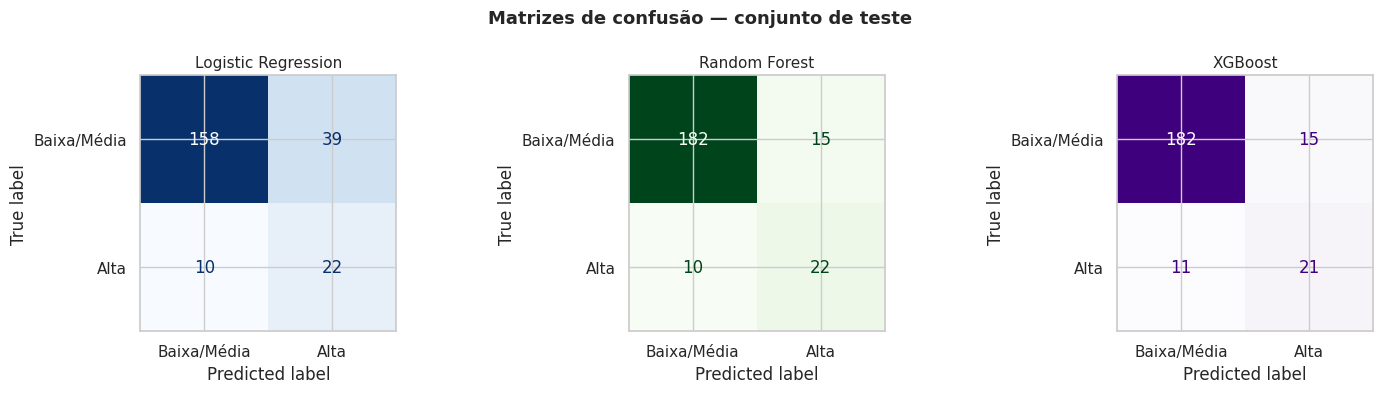

In [ ]:
# Matrizes de confusão — lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nomes = list(results.keys())
cores = [plt.cm.Blues, plt.cm.Greens, plt.cm.Purples]

for i, nome in enumerate(nomes):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=results[nome]['cm'],
        display_labels=['Baixa/Média', 'Alta']
    )
    disp.plot(ax=axes[i], cmap=cores[i], colorbar=False)
    axes[i].set_title(nome, fontsize=11)

plt.suptitle('Matrizes de confusão — conjunto de teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/07_matrizes_confusao.png', bbox_inches='tight')
plt.show()


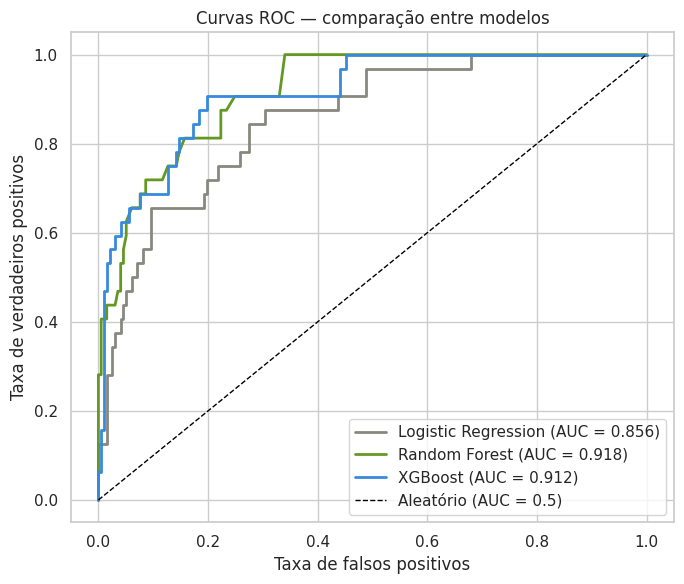

In [ ]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
cores_roc = {'Logistic Regression': '#888780', 'Random Forest': '#639922', 'XGBoost': '#378ADD'}

for nome, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{nome} (AUC = {r['roc_auc']:.3f})",
            color=cores_roc[nome], linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de falsos positivos')
ax.set_ylabel('Taxa de verdadeiros positivos')
ax.set_title('Curvas ROC — comparação entre modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('results/08_curvas_roc.png', bbox_inches='tight')
plt.show()


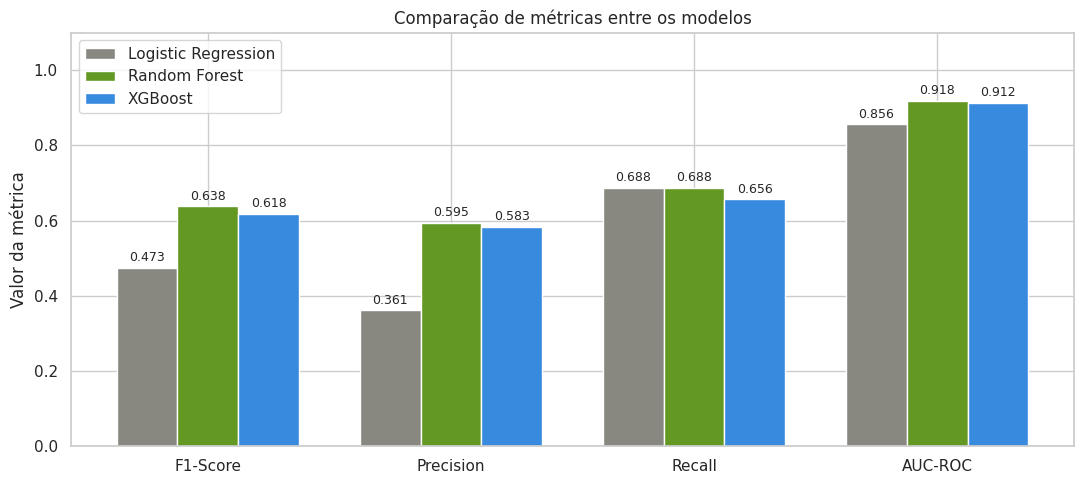

In [ ]:
# Gráfico comparativo de métricas
metricas = ['F1-Score', 'Precision', 'Recall', 'AUC-ROC']
x = np.arange(len(metricas))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

for i, (nome, r) in enumerate(results.items()):
    vals = [r['f1'], r['precision'], r['recall'], r['roc_auc']]
    bars = ax.bar(x + i*width, vals, width, label=nome,
                  color=list(cores_roc.values())[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor da métrica')
ax.set_title('Comparação de métricas entre os modelos')
ax.legend()
plt.tight_layout()
plt.savefig('results/09_comparacao_metricas.png', bbox_inches='tight')
plt.show()


## 7. Interpretação dos resultados

### 7.1 Importância das variáveis (Random Forest)


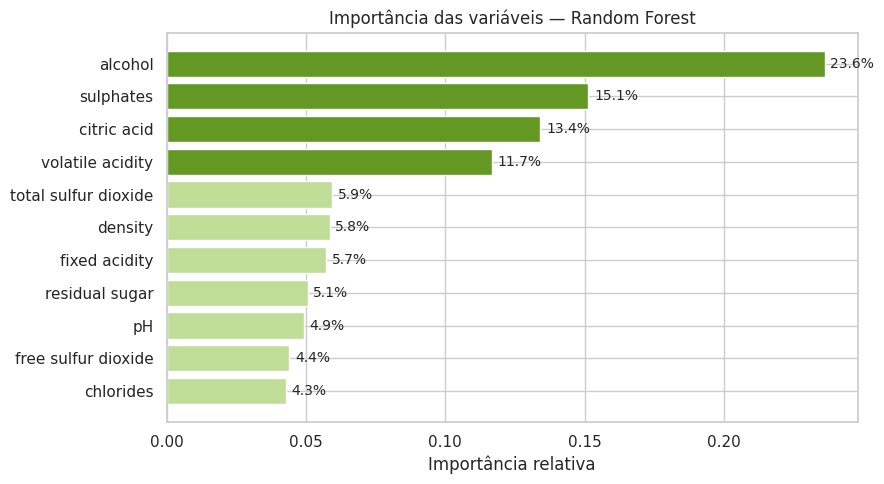


Importância das variáveis:
  alcohol                       : 23.6%
  sulphates                     : 15.1%
  citric acid                   : 13.4%
  volatile acidity              : 11.7%
  total sulfur dioxide          : 5.9%
  density                       : 5.8%
  fixed acidity                 : 5.7%
  residual sugar                : 5.1%
  pH                            : 4.9%
  free sulfur dioxide           : 4.4%
  chlorides                     : 4.3%


In [ ]:
rf_model = trained['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cores_fi = ['#639922' if v >= 0.10 else '#C0DD97' for v in fi.values]
ax.barh(fi.index, fi.values, color=cores_fi)
ax.set_xlabel('Importância relativa')
ax.set_title('Importância das variáveis — Random Forest')
for i, v in enumerate(fi.values):
    ax.text(v + 0.002, i, f'{v:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('results/10_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nImportância das variáveis:')
for feat, imp in fi.sort_values(ascending=False).items():
    print(f'  {feat:30s}: {imp:.1%}')


### 7.2 Análise das médias por classe — implicações para produção

In [ ]:
# ── Gráfico de médias por classe — comparação visual completa ───────────────
from sklearn.preprocessing import StandardScaler

# Calcular médias por classe
medias = df.groupby('quality_category')[features].mean()

# Calcular diferença percentual de cada variável entre as classes
diffs = {}
for feat in features:
    alta  = medias.loc['Alta qualidade', feat]
    baixa = medias.loc['Baixa/Média qualidade', feat]
    diffs[feat] = (alta - baixa) / abs(baixa) * 100

diff_series = pd.Series(diffs).sort_values()

# Normalizar os valores (z-score) para permitir comparação na mesma escala
scaler_viz = StandardScaler()
X_norm = scaler_viz.fit_transform(df[features])
df_norm = pd.DataFrame(X_norm, columns=features)
df_norm['quality_category'] = df['quality_category'].values
medias_norm = df_norm.groupby('quality_category')[features].mean()

# ── Figura com dois painéis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Painel esquerdo: diferença percentual ordenada ───────────────────────────
cores_diff = ['#D85A30' if v < 0 else '#639922' for v in diff_series.values]
bars = axes[0].barh(
    diff_series.index, diff_series.values,
    color=cores_diff, alpha=0.85, height=0.6
)
axes[0].axvline(0, color='#2E4057', linewidth=1.2, linestyle='--')

for bar, val in zip(bars, diff_series.values):
    sinal  = '+' if val >= 0 else ''
    x_pos  = val + 1.8 if val >= 0 else val - 1.8
    ha     = 'left'    if val >= 0 else 'right'
    axes[0].text(
        x_pos, bar.get_y() + bar.get_height() / 2,
        f'{sinal}{val:.1f}%', va='center', ha=ha,
        fontsize=10, fontweight='bold', color='#2E4057'
    )

axes[0].set_xlabel('Diferença percentual (Alta vs Baixa/Média)', fontsize=11)
axes[0].set_title(
    'Diferença relativa entre classes\n'
    '(verde = mais alto em vinhos bons  ·  vermelho = mais baixo)',
    fontsize=11
)
axes[0].set_xlim(-48, 80)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Painel direito: médias normalizadas (z-score) lado a lado ────────────────
x     = np.arange(len(features))
width = 0.35

axes[1].bar(
    x - width / 2, medias_norm.loc['Alta qualidade'],
    width, label='Alta qualidade', color='#639922', alpha=0.85
)
axes[1].bar(
    x + width / 2, medias_norm.loc['Baixa/Média qualidade'],
    width, label='Baixa/Média qualidade', color='#378ADD', alpha=0.85
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(features, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel('Valor normalizado (z-score)', fontsize=11)
axes[1].set_title(
    'Médias normalizadas por classe\n'
    '(mesma escala para todas as variáveis)',
    fontsize=11
)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    'Comparação das médias por classe de qualidade',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('results/11_medias_por_classe.png', bbox_inches='tight')
plt.show()


### 💡 Como ler esses dois painéis

**Painel esquerdo — Diferença percentual:**
Mostra *o quanto* cada variável difere entre vinhos bons e comuns, em percentual relativo, ordenado do maior impacto negativo ao maior positivo. É o painel mais direto para comunicar aos diretores — "vinhos de alta qualidade têm 57% mais ácido cítrico e 29% menos acidez volátil".

**Painel direito — Médias normalizadas (z-score):**
Coloca todas as variáveis na mesma escala (média 0, desvio 1), permitindo comparar visualmente aquelas com unidades completamente diferentes — sem normalização, `total sulfur dioxide` (valores ~40) dominaria o gráfico e `chlorides` (valores ~0,08) ficaria invisível.

#### Leitura combinada dos resultados

| Variável | Diferença | Interpretação para produção |
|---|---|---|
| `citric acid` | **+57%** | Maior impacto relativo — frescor e equilíbrio sensorial |
| `volatile acidity` | **-29%** | Principal sinal de defeito — controle de higiene e oxidação |
| `sulphates` | **+16%** | Conservação adequada do vinho durante envelhecimento |
| `total sulfur dioxide` | **-23%** | Menos intervenção química — processo mais controlado |
| `alcohol` | **+12%** | Fermentação mais completa — indicador chave de qualidade |
| `density` | **-0,1%** | Diferença mínima — pouco discriminativo isoladamente |
| `pH` | **-1,0%** | Diferença mínima — pouco discriminativo isoladamente |


In [ ]:
# Média de cada variável por classe
medias = df.groupby('quality_category')[features].mean().T
medias['diferença'] = medias['Alta qualidade'] - medias['Baixa/Média qualidade']
medias['diferença_%'] = (medias['diferença'] / medias['Baixa/Média qualidade'] * 100).round(1)
medias = medias.sort_values('diferença_%', ascending=False)

print('Média por classe e diferença percentual:')
print(medias[['Alta qualidade', 'Baixa/Média qualidade', 'diferença_%']].round(3).to_string())


Média por classe e diferença percentual:
quality_category      Alta qualidade  Baixa/Média qualidade  diferença_%
citric acid                    0.391                  0.249         57.4
sulphates                      0.746                  0.643         15.9
alcohol                       11.528                 10.267         12.3
residual sugar                 2.748                  2.497         10.1
fixed acidity                  8.847                  8.225          7.6
density                        0.996                  0.997         -0.1
pH                             3.282                  3.316         -1.0
free sulfur dioxide           14.189                 15.846        -10.5
chlorides                      0.075                  0.089        -16.0
total sulfur dioxide          36.673                 47.408        -22.6
volatile acidity               0.395                  0.553        -28.6


### 7.3 Conclusões e implicações para o processo produtivo

**Principais achados:**

| Variável | Direção | Interpretação prática |
|---|---|---|
| `alcohol` | Alta qualidade tem +12% mais | Fermentação mais completa — uvas mais maduras ou processo mais longo |
| `sulphates` | Alta qualidade tem +16% mais | Melhor conservação e proteção contra oxidação |
| `citric acid` | Alta qualidade tem +57% mais | Maior frescor e equilíbrio sensorial |
| `volatile acidity` | Alta qualidade tem -29% menos | Menos ácido acético — menor risco de contaminação bacteriana |
| `total sulfur dioxide` | Alta qualidade tem -23% menos | Menor intervenção química no processo |

**Recomendações para produção:**
1. Monitorar o teor alcoólico ao fim da fermentação — lotes abaixo de 10,5% são candidatos a revisão
2. Implementar medição rotineira de acidez volátil — valores acima de 0,6 g/L indicam problema bacteriano
3. Ajustar sulfatos entre 0,65 e 0,85 g/L como faixa alvo de qualidade
4. Usar o modelo como triagem antes da avaliação sensorial do enólogo

**Limitações do modelo:**
- Treinado exclusivamente com vinho tinto — não aplicável a brancos ou rosés
- Recall de 69% na classe alta: 31% dos vinhos bons ainda são classificados incorretamente
- Variáveis sensoriais (aroma, cor, textura) não estão no dataset


### 7.4 Resumo final do desempenho

In [ ]:
print('=' * 60)
print('  RESUMO FINAL — WINE QUALITY CLASSIFICATION')
print('=' * 60)
print()

melhor = max(results, key=lambda k: results[k]['f1'])
r = results[melhor]

print(f'  Melhor modelo    : {melhor}')
print(f'  F1-Score         : {r["f1"]:.4f}')
print(f'  Precision        : {r["precision"]:.4f}')
print(f'  Recall           : {r["recall"]:.4f}')
print(f'  AUC-ROC          : {r["roc_auc"]:.4f}')
print()
print('  Comparativo completo:')
print(comp.to_string())
print()
print('  Variável mais importante: alcohol (23.6%)')
print('  Variável de maior risco : volatile acidity (-0.407 com quality)')


  RESUMO FINAL — WINE QUALITY CLASSIFICATION

  Melhor modelo    : Random Forest
  F1-Score         : 0.6377
  Precision        : 0.5946
  Recall           : 0.6875
  AUC-ROC          : 0.9180

  Comparativo completo:
                     F1-Score  Precision  Recall  AUC-ROC
Logistic Regression    0.4731     0.3607  0.6875   0.8560
Random Forest          0.6377     0.5946  0.6875   0.9180
XGBoost                0.6176     0.5833  0.6562   0.9124

  Variável mais importante: alcohol (23.6%)
  Variável de maior risco : volatile acidity (-0.407 com quality)
